In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from pathlib import Path
import itables
from matplotlib.patches import Patch

BG    = '#F8F5F0'
DARK  = '#1C1C2E'
MID   = '#5A5A7A'
GRID  = '#E2DDD6'
WIN = '#648FFF'
FUN = '#DC267F'
GREEN = '#009E73'   # direction matches prediction
RED   = '#D55E00'   # direction against prediction
COND_COLOR = {'FUN': FUN, 'WIN': WIN}

cm = 1 / 2.54

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'axes.edgecolor': GRID,
    'axes.labelcolor': MID, 'xtick.color': MID, 'ytick.color': MID,
    'text.color': DARK, 'font.size': 9, 'axes.titlesize': 10,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.facecolor': BG,
})

def style_ax(ax, title=None):
    ax.set_facecolor(BG)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(length=3, width=0.8)
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold', color=DARK, pad=8)

def paired_dot(ax, pivoted, expected='+', xjitter=0.06,
               point_size=55, line_alpha=0.55, line_lw=1.4,
               point_alpha=0.85, rng_seed=0):
    """
    Draw a paired-dot (slope) plot with direction-coloured connecting lines.

    Parameters
    ----------
    pivoted   : DataFrame indexed by unit (player or group), columns must be ['FUN','WIN'].
    expected  : '+' if FUN > WIN is the predicted direction, '-' if FUN < WIN is.
                Lines are GREEN when the unit's slope matches the prediction, RED otherwise.
    xjitter   : sd of horizontal jitter (0 = no jitter).
    """
    rng  = np.random.default_rng(rng_seed)
    xs   = {'WIN': 0.0, 'FUN': 1.0}
    n    = len(pivoted)
    jx_F = rng.normal(0, xjitter, n)
    jx_W = rng.normal(0, xjitter, n)
    

    for (i, (_, row)) in enumerate(pivoted.iterrows()):
        f, w = row['FUN'], row['WIN']
        if pd.isna(f) or pd.isna(w):
            continue
        diff_signed = (f - w) if expected == '+' else (w - f)
        line_color  = GREEN if diff_signed > 0 else (RED if diff_signed < 0 else MID)
        ax.plot([xs['FUN'] + jx_F[i], xs['WIN'] + jx_W[i]], [f, w],
                color=line_color, alpha=line_alpha, lw=line_lw, zorder=1)
        ax.scatter(xs['FUN'] + jx_F[i], f, color=FUN, s=point_size,
                   alpha=point_alpha, edgecolor='white', lw=0.6, zorder=3)
        ax.scatter(xs['WIN'] + jx_W[i], w, color=WIN, s=point_size,
                   alpha=point_alpha, edgecolor='white', lw=0.6, zorder=3)

    ax.set_xticks([0, 1]); ax.set_xticklabels(['WIN', 'FUN'])
    ax.set_xlim(-0.45, 1.45)

rng = np.random.default_rng(0)

In [2]:
CLEAN_DIR = Path('../data')

entropy_df     = pd.read_csv(CLEAN_DIR / 'entropy.csv')
entropy_df     = entropy_df.sort_values(['group', 'round', 'timestamp']).reset_index(drop=True)
groups = entropy_df['group'].unique()

print('Child groups:', groups)
print('n groups:', len(groups))

FileNotFoundError: [Errno 2] No such file or directory: '../data/entropy.csv'

In [ ]:
itables.show(entropy_df)

Loading ITables v2.7.0 from the internet... (need help?)


# Rule violations

In [ ]:
pattern_counts = []

for (grp, rnd), sub in entropy_df.sort_values(['group', 'round', 'timestamp']).groupby(['group', 'round']):
    tags = sub['player_tagged'].tolist()
    count = 0
    for i in range(len(tags) - 2):
        a, b, c = tags[i], tags[i + 1], tags[i + 2]
        if pd.notna(a) and pd.notna(b) and pd.notna(c):
            if a == c and a != b:
                count += 1

    pattern_counts.append({
        'group': grp,
        'round': rnd,
        'condition': sub['condition'].iloc[0],
        'aba_count': count
    })

pattern_counts_df = pd.DataFrame(pattern_counts)

#print("A->B->A counts by group and round")
#print(pattern_counts_df.sort_values(['group', 'round']).to_string(index=False))

print("\nTotal A->B->A counts by group")
group_totals = pattern_counts_df.groupby('group', sort=True)['aba_count'].sum()
print(group_totals.to_string())

print("\nTotal A->B->A counts by condition")
condition_totals = pattern_counts_df.groupby('condition')['aba_count'].sum()
print(condition_totals.to_string())

print("\nOverall total A->B->A count")
print(int(condition_totals.sum()))


Total A->B->A counts by group
group
A    4
B    1
C    3
D    4
E    8
G    0
H    2
J    5

Total A->B->A counts by condition
condition
FUN    18
WIN     9

Overall total A->B->A count
27


## Entropy function

Transition entropy H(next target | current tagger) computed from the ordered sequence of tagged players within a round.

**What it measures:** for each tagger, how uniformly distributed are their tag targets? A tagger who always tags the same player gets H = 0; a tagger who distributes tags equally across all others gets the maximum. The per-row entropies are weighted by how often each player appeared as tagger and averaged.

**Miller-Madow correction** adjusts for the downward bias of empirical entropy at small sample sizes: `H_corrected = H_naive + (k - 1) / (2n)` where k is the number of non-zero probability targets and n is the number of transitions from this tagger.

**Normalisation** divides by `log2(n_players)` to put values on a 0–1 scale, making groups and rounds with different player counts comparable. Group C rounds 3–4 had 4 players (one left); the override dict handles this.

In [ ]:
def transition_entropy(seq, n_players):
    """
    Compute weighted conditional entropy H(next_target | current_tagger)
    from an ordered sequence of tagged player IDs within one round.

    Parameters
    ----------
    seq       : array-like of int  — ordered player IDs who were tagged
    n_players : int                — number of active players this round

    Returns
    -------
    float  — Miller-Madow corrected, weighted entropy in bits,
             normalised to [0, 1] relative to log2(n_players - 1).
             NaN if the sequence has fewer than 2 events.
    """
    seq = np.asarray(seq)
    if len(seq) < 2:
        return np.nan

    # Number of legally valid targets per tagger, allowing tag-backs but not self-tags
    n_valid_targets = n_players - 1
    h_max = np.log2(n_valid_targets)   # ceiling for normalisation

    # Build transition count matrix counts[i, j] = number of times
    # player i (as tagger) tagged player j next.
    n = max(int(seq.max()) + 1, n_players + 1)
    counts = np.zeros((n, n), dtype=float)
    for a, b in zip(seq[:-1], seq[1:]):
        counts[int(a), int(b)] += 1

    # Diagonal = self-tags (impossible; zero if data is clean)
    np.fill_diagonal(counts, 0)

    row_totals = counts.sum(axis=1)
    total = row_totals.sum()
    if total == 0:
        return np.nan

    row_H = []
    row_w = []
    for i in range(n):
        ni = row_totals[i]
        if ni == 0:
            continue  # player never appeared as tagger in this round

        p = counts[i] / ni
        nonzero = p > 0

        # Shannon entropy of this row's distribution
        h_naive = -np.sum(p[nonzero] * np.log2(p[nonzero]))

        # Miller-Madow correction for small-sample bias
        k      = nonzero.sum()
        h_corr = h_naive + (k - 1) / (2 * ni)

        row_H.append(h_corr)
        row_w.append(ni)

    weights = np.array(row_w) / total
    h_weighted = float(np.sum(weights * np.array(row_H)))

    # Normalise to [0, 1] relative to the legal action space
    return h_weighted / h_max


# n_players override for rounds where the roster changed mid-session
N_OVERRIDE = {('C', 3): 4, ('C', 4): 4}   # one player left Group C after round 2

def n_players_in_round(group, round_num, default=5):
    return N_OVERRIDE.get((group, round_num), default)

In [ ]:
events_clean = entropy_df.dropna(subset=['player_tagged']).copy()

# ── Per (group, condition): mean normalised entropy across rounds ─────────────
# Used for the paired dot plot (Plot 1).
ent_records = []
for (g, c), sub in events_clean.groupby(['group', 'condition']):
    h_list = []
    for r, rsub in sub.groupby('round'):
        n_p = n_players_in_round(g, r)
        h   = transition_entropy(rsub['player_tagged'].values, n_p)
        if not np.isnan(h):
            h_list.append(h)
    if h_list:
        ent_records.append({'group': g, 'condition': c,
                            'entropy_norm': np.mean(h_list)})

ent_wide = (pd.DataFrame(ent_records)
              .pivot(index='group', columns='condition', values='entropy_norm'))
print('Mean normalised entropy per group × condition:')
print(ent_wide.round(3))

# ── Per round (long form): for encounter analysis (Plot 2) ───────────────────
per_round = []
for (g, r, c), sub in events_clean.groupby(['group', 'round', 'condition']):
    n_p = n_players_in_round(g, r)
    h   = transition_entropy(sub['player_tagged'].values, n_p)
    if not np.isnan(h):
        per_round.append({'group': g, 'round': r, 'condition': c,
                          'entropy_norm': h })

ent_long = (pd.DataFrame(per_round)
              .sort_values(['group', 'condition', 'round'])
              .reset_index(drop=True))
# encounter = 1st or 2nd time this group played this condition
ent_long['encounter'] = ent_long.groupby(['group', 'condition']).cumcount() + 1

Mean normalised entropy per group × condition:
condition    FUN    WIN
group                  
A          0.867  0.513
B          0.399  0.269
C          0.628  0.412
D          0.690  0.358
E          0.928  0.757
G          0.831  0.531
H          0.704  0.530
J          0.803  0.599


In [ ]:
# ── Summary table: Mean & SD by condition × encounter ───────────────────────
print('\n' + '                  |Mean |SD   |')
for cond, enc in [('FUN', 1), ('FUN', 2), ('WIN', 1), ('WIN', 2)]:
    subset = ent_long[(ent_long['condition']==cond) & (ent_long['encounter']==enc)]['entropy_norm']
    mean = subset.mean()
    sd = subset.std()
    enc_label = f"{enc}{'st' if enc == 1 else 'nd'}"
    print(f'|{enc_label} encounter {cond}|{mean:.3f}|{sd:.3f}|')


                  |Mean |SD   |
|1st encounter FUN|0.631|0.248|
|2nd encounter FUN|0.832|0.122|
|1st encounter WIN|0.423|0.231|
|2nd encounter WIN|0.570|0.101|


In [ ]:
mean_fun = ent_wide['FUN'].mean()
mean_win = ent_wide['WIN'].mean()
diff = mean_fun - mean_win

print(f"Mean FUN: {mean_fun:.3f}")
print(f"Mean WIN: {mean_win:.3f}")
print(f"Difference (FUN - WIN): {diff:.3f}")

Mean FUN: 0.731
Mean WIN: 0.496
Difference (FUN - WIN): 0.235


In [ ]:
#Print length of longest and shortest sequences from ent_wide
sequences = []
for (g, c), sub in events_clean.groupby(['group', 'condition']):
    for r, rsub in sub.groupby('round'):
        seq = rsub['player_tagged'].dropna().values
        sequences.append({'group': g, 'condition': c, 'round': r, 'length': len(seq)})
seq_df = pd.DataFrame(sequences)
max_length = seq_df['length'].max()
min_length = seq_df['length'].min()
print(f"\nLongest sequence length: {max_length}")
print(f"Shortest sequence length: {min_length}")


Longest sequence length: 51
Shortest sequence length: 6


In [ ]:
itables.show(ent_long)

Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
#investigate why one group has exactly 0 entropy
seq = entropy_df[(entropy_df['group'] == 'C') & (entropy_df['round'] == 1)]['player_tagged'].tolist()
print(seq)

[4.0, 3.0, 2.0, 4.0, 5.0, 2.0, 4.0]


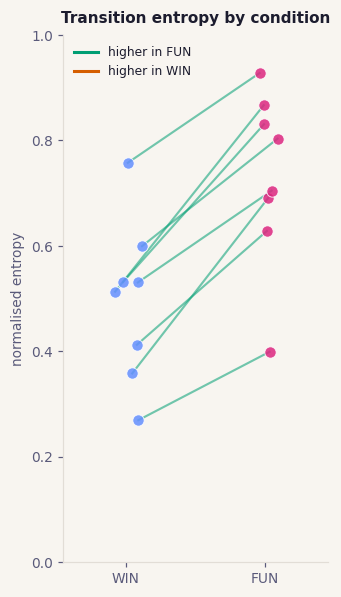

In [ ]:
# ── Plot 1: Entropy by condition (paired dot) ─────────────────────────────
# Line colour = GREEN when FUN > WIN (predicted), RED when WIN > FUN (against).

fig, ax = plt.subplots(figsize=(8 * cm, 5.5))

xs = {'WIN': 0.0, 'FUN': 1.0}
n  = len(ent_wide)
jx_F = rng.normal(0, 0.06, n)
jx_W = rng.normal(0, 0.06, n)

for i, (g, row) in enumerate(ent_wide.iterrows()):
    f, w = row['FUN'], row['WIN']
    if pd.isna(f) or pd.isna(w):
        continue
    color = GREEN if f > w else RED
    ax.plot([xs['FUN'] + jx_F[i], xs['WIN'] + jx_W[i]], [f, w],
            color=color, alpha=0.55, lw=1.4, zorder=1)
    ax.scatter(xs['FUN'] + jx_F[i], f, color=FUN, s=55,
               alpha=0.85, edgecolor='white', lw=0.6, zorder=3)
    ax.scatter(xs['WIN'] + jx_W[i], w, color=WIN, s=55,
               alpha=0.85, edgecolor='white', lw=0.6, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['WIN', 'FUN'])
ax.set_xlim(-0.45, 1.45)
ax.set_ylabel('normalised entropy')
ax.set_ylim(0, 1)
ax.legend(
    handles=[
        Line2D([], [], color=GREEN, lw=2, label='higher in FUN'),
        Line2D([], [], color=RED,   lw=2, label='higher in WIN'),
    ],
    loc='upper left', frameon=False, fontsize=8,
)
style_ax(ax, title='Transition entropy by condition')
fig.tight_layout()
plt.show()
fig.savefig('../plots/entropy_by_condition.png', dpi=300, bbox_inches='tight')

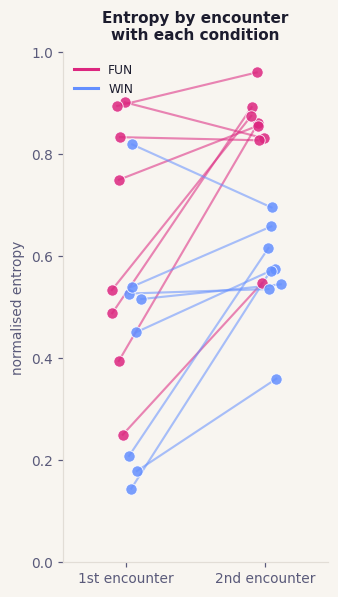

In [ ]:
# ── Plot 2: Entropy by encounter with each condition ─────────────────────
# Matches Plot 1: same figure size, y-limits, and legend styling.
# FUN and WIN lines are offset slightly on the x-axis so they don't overlap.

fig, ax = plt.subplots(figsize=(8 * cm, 5.5))

xbase = {1: 0.0, 2: 1.0}              # encounter 1 left, encounter 2 right
xoff  = {'FUN': -0.06, 'WIN': 0.06}  # slight stagger per condition

for cond, color in COND_COLOR.items():
    sub         = ent_long[ent_long['condition'] == cond]
    group_list  = sorted(sub['group'].unique())
    jx          = rng.normal(0, 0.03, len(group_list))
    for ji, g in enumerate(group_list):
        gsub = sub[sub['group'] == g].sort_values('encounter')
        if len(gsub) != 2:
            continue
        xs_pts = [xbase[e] + xoff[cond] + jx[ji] for e in gsub['encounter'].values]
        ax.plot(xs_pts, gsub['entropy_norm'].values,
                color=color, lw=1.4, alpha=0.55, zorder=1)
        ax.scatter(xs_pts, gsub['entropy_norm'].values,
                   color=color, s=55, alpha=0.85,
                   edgecolor='white', lw=0.6, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['1st encounter', '2nd encounter'])
ax.set_xlim(-0.45, 1.45)
ax.set_ylabel('normalised entropy')
ax.set_ylim(0, 1)
ax.legend(
    handles=[
        Line2D([], [], color=FUN, lw=2, label='FUN'),
        Line2D([], [], color=WIN, lw=2, label='WIN'),
    ],
    loc='upper left', frameon=False, fontsize=8,
)
style_ax(ax, title='Entropy by encounter\nwith each condition')
fig.tight_layout()
plt.show()
fig.savefig('../plots/entropy_by_encounter.png', dpi=300, bbox_inches='tight')

/var/folders/fy/dq076l2x6h193qvwcs1f0qm00000gn/T/ipykernel_2605/204176343.py:286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


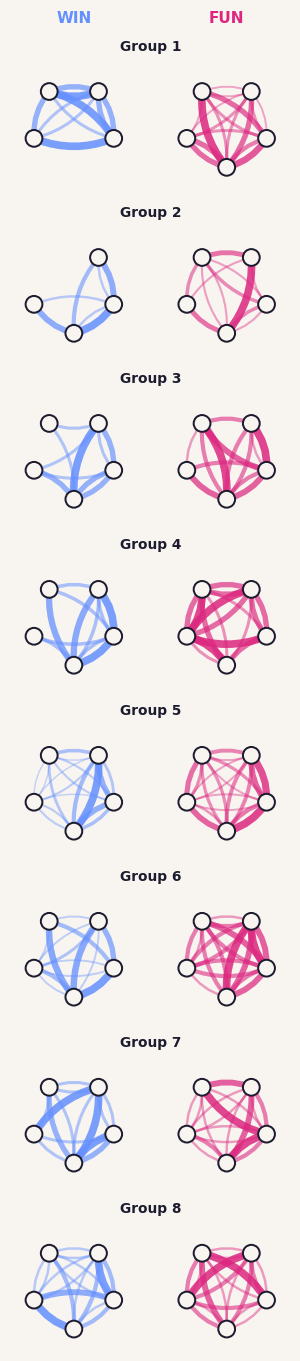

In [ ]:
# ── Network helper setup ──────────────────────────────────────────────────
# Build directed tagging events:
# "tagger" = previous tagged player within each round.

ev_net = (
    entropy_df.sort_values(['group', 'round', 'timestamp'])
      .reset_index(drop=True)
)

ev_net['tagger'] = (
    ev_net.groupby(['group', 'round'])['player_tagged']
          .shift(1)
)

ev_net = (
    ev_net.dropna(subset=['tagger', 'player_tagged'])
          .copy()
)

ev_net['tagger'] = ev_net['tagger'].astype(int)
ev_net['player_tagged'] = ev_net['player_tagged'].astype(int)


# ── Edge counts ───────────────────────────────────────────────────────────
# One row = directed edge frequency within a condition.

edges_g = (
    ev_net
    .groupby(
        ['group', 'condition', 'tagger', 'player_tagged'],
        as_index=False
    )
    .size()
    .rename(columns={'size': 'count'})
)


# ── Node totals ───────────────────────────────────────────────────────────

node_totals = (
    ev_net
    .groupby(
        ['group', 'condition', 'player_tagged'],
        as_index=False
    )
    .size()
    .rename(columns={'size': 'n_tags'})
)


# ── Stable node positions ────────────────────────────────────────────────
# Positions are based on OVERALL tagging frequency across BOTH conditions.
# This keeps the same player in the same position for WIN and FUN.

overall_totals = (
    ev_net
    .groupby(['group', 'player_tagged'], as_index=False)
    .size()
    .rename(columns={'size': 'n_total'})
)

overall_totals['rank'] = (
    overall_totals
    .groupby('group')['n_total']
    .rank(method='first', ascending=False)
    .astype(int)
)

rank_g = {
    (g, p): r
    for g, p, r in zip(
        overall_totals['group'],
        overall_totals['player_tagged'],
        overall_totals['rank']
    )
}


# ── Circular layout ──────────────────────────────────────────────────────
# Rank 1 at top, then clockwise.

POS = {
    i: np.array([
        np.cos(-np.pi/2 + 2*np.pi*(i-1)/5),
        np.sin(-np.pi/2 + 2*np.pi*(i-1)/5)
    ])
    for i in range(1, 6)
}


# ── Node size function ───────────────────────────────────────────────────
# x is normalized tagging frequency from 0→1.

def node_radius(x):
    return 0.04 + 0.33 * (x ** 1.5)


# ── Draw one network ─────────────────────────────────────────────────────

def draw_network(ax, group, condition, color, max_lw=4.5):

    # --- Edges for this panel ---
    sub_edges = edges_g[
        (edges_g['group'] == group) &
        (edges_g['condition'] == condition)
    ].copy()

    # --- Node totals for this panel ---
    sub_nodes = node_totals[
        (node_totals['group'] == group) &
        (node_totals['condition'] == condition)
    ].copy()

    # --- Scaling constants ---
    edge_max = (
        sub_edges['count'].max()
        if len(sub_edges) else 1
    )

    node_max = (
        sub_nodes['n_tags'].max()
        if len(sub_nodes) else 1
    )

    # ── Draw edges ───────────────────────────────────────────────────────

    for _, row in sub_edges.iterrows():

        tagger_rank = rank_g.get(
            (group, int(row['tagger']))
        )

        tagged_rank = rank_g.get(
            (group, int(row['player_tagged']))
        )

        if (
            tagger_rank is None or
            tagged_rank is None or
            tagger_rank == tagged_rank
        ):
            continue

        w = row['count'] / edge_max

        ax.annotate(
            '',
            xy=POS[tagged_rank],
            xytext=POS[tagger_rank],
            arrowprops=dict(
                arrowstyle='-',
                connectionstyle='arc3,rad=0.20',
                color=color,
                lw=0.5 + max_lw * w,
                alpha=0.30 + 0.55 * w,
            ),
            zorder=2
        )

    # ── Draw nodes ───────────────────────────────────────────────────────

    for _, row in sub_nodes.iterrows():

        pid = int(row['player_tagged'])
        n   = row['n_tags']

        r = rank_g.get((group, pid))

        if r is None:
            continue

        x, y = POS[r]

        normalized = n / node_max
        rad = node_radius(normalized)
        rad = 0.2

        ax.add_patch(
            Circle(
                (x, y),
                rad,
                facecolor=BG,
                edgecolor=DARK,
                linewidth=1.3,
                zorder=3
            )
        )

    # ── Styling ──────────────────────────────────────────────────────────

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor(BG)


# ── Plot small multiples ────────────────────────────────────────────────

n_groups = len(groups)

fig, axes = plt.subplots(
    n_groups,
    2,
    figsize=(3.5, n_groups * 1.9),
    gridspec_kw={
        'wspace': 0.05,
        'hspace': 0.32
    }
)

fig.patch.set_facecolor(BG)


# ── Column headers ──────────────────────────────────────────────────────

for col_i, (cond, color) in enumerate([
    ('WIN', WIN),
    ('FUN', FUN)
]):

    ax_pos = axes[0, col_i].get_position()

    fig.text(
        (ax_pos.x0 + ax_pos.x1) / 2,
        ax_pos.y1 + 0.022,
        cond,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=color
    )


# ── Draw all groups ─────────────────────────────────────────────────────

for row_i, g in enumerate(groups):

    draw_network(
        axes[row_i, 0],
        g,
        'WIN',
        WIN
    )

    draw_network(
        axes[row_i, 1],
        g,
        'FUN',
        FUN
    )

    # Group label centered above pair

    left_pos = axes[row_i, 0].get_position()
    right_pos = axes[row_i, 1].get_position()

    mid_x = (left_pos.x0 + right_pos.x1) / 2
    top_y = left_pos.y1

    fig.text(
        mid_x,
        top_y + 0.005,
        f'Group {row_i + 1}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=DARK
    )

fig.tight_layout()
plt.show()
fig.savefig('../plots/entropy_networks.png', dpi=300, bbox_inches='tight')